<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/GMTED_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topography Maps usind Data Science with Python

## Introduction

Certainly! Here's a more **academic and extensive** version of the introduction on *Topographic Maps Using Data Science with Python*:

---

## **Introduction: Topographic Mapping through Data Science with Python**

Topographic maps are essential cartographic representations that depict the elevation and relief of the Earth’s surface through the use of contour lines, color gradients, and shaded relief. These maps are fundamental tools in a wide array of disciplines, including geomorphology, hydrology, civil engineering, environmental planning, and natural hazard assessment. Traditionally produced through field surveys and photogrammetric techniques, the generation and analysis of topographic data has been profoundly transformed by the advent of geospatial data science and the widespread availability of remote sensing datasets.

In the context of data science, topographic mapping involves the acquisition, processing, analysis, and visualization of elevation data using computational tools. Python, due to its simplicity, versatility, and extensive ecosystem of geospatial libraries, has become a language of choice for performing such tasks. The integration of libraries such as `rasterio` for raster data manipulation, `elevation` for retrieving digital elevation models (DEMs), `cartopy` for cartographic projections and overlays, and `matplotlib` or `pygmt` for visualization enables the creation of high-resolution, aesthetically compelling topographic maps with minimal manual intervention.

These libraries facilitate the automated processing of satellite-derived elevation models, such as the Shuttle Radar Topography Mission (SRTM) and Earth Relief datasets, allowing researchers to focus on the analysis and interpretation of the terrain. Applications include the generation of contour maps, slope and aspect models, hillshading for visual enhancement, and the integration of hydrological or geological layers for multi-criteria analysis. Moreover, Python’s integration with scientific computing frameworks makes it possible to couple topographic data with machine learning or statistical models for tasks such as landslide susceptibility mapping, watershed delineation, or terrain classification.

This study aims to explore the use of Python-based data science tools for the generation and analysis of topographic maps, with a particular focus on the territory of France. France’s diverse terrain, which includes coastal plains, river basins, highland plateaus, and alpine regions, presents an ideal case for demonstrating both the technical workflow and the cartographic richness that can be achieved through programmatic methods. By leveraging open-access elevation data and modern computational tools, we aim to produce maps that are not only scientifically accurate but also visually informative, highlighting the capabilities of open-source technologies in contemporary geospatial analysis.

## 'pygmt':

'pygmt' is a powerful Python wrapper for the Generic Mapping Tools (GMT), designed to create high-quality, publication-ready maps, especially topographic and geospatial visualizations.

Step to step:

1. Define the geographical region (bounding box for France).

2. Fetch global elevation data from the built-in GMT dataset (@earth_relief_03m).

3. Apply shaded relief (to simulate 3D terrain with lighting).

4. Add topographic color gradient (e.g., GMT’s geo colormap).

5. Overlay coastlines, borders, and a frame.

6. Render and display the map.

---
**Install pygmt y dependencias colab** *gmt gmt-common gmt-gshhg gmt-dcw*

---

In [ ]:
!pip install pygmt -q

!apt-get install -y gmt gmt-common gmt-gshhg gmt-dcw

import os
# Set the LD_LIBRARY_PATH to include the directory where libgmt.so is installed
os.environ['LD_LIBRARY_PATH'] = '/usr/lib/x86_64-linux-gnu/'

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
gmt-dcw is already the newest version (2.1.0-1).
gmt-gshhg is already the newest version (2.3.7-5).
gmt is already the newest version (6.4.0+dfsg-2~jammy1).
gmt-common is already the newest version (6.4.0+dfsg-2~jammy1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [ ]:
import pygmt

# Región geográfica de Francia (aproximada)
region = [-5, 10, 41, 52]

# Crear la figura
fig = pygmt.Figure()

# Mostrar la elevación topográfica con sombreado
fig.grdimage(
    grid="@earth_relief_03m",     # Malla global con resolución de 3 minutos de arco
    region=region,
    projection="M15c",            # Proyección Mercator, ancho de 15 cm
    shading=True,                 # Sombreado automático
    cmap="geo",                   # Colormap para topografía
    frame=["af", "+t'Topographic Map of France'"]
)

# Añadir costas y fronteras
fig.coast(
    shorelines="1/0.25p,black",
    borders="1/0.5p,black",
    resolution="10m"
)

# Mostrar el mapa
fig.show()


GMTCLibNotFoundError: Error loading GMT shared library at 'libgmt.so'.
libgmt.so: cannot open shared object file: No such file or directory

In [ ]:
# Instalar GMT (puede tardar ~2 min)
!apt-get install -y gmt gmt-common gmt-gshhg gmt-dcw
# Instalar PyGMT desde pip
!pip install -q pygmt


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
gmt-dcw is already the newest version (2.1.0-1).
gmt-gshhg is already the newest version (2.3.7-5).
gmt is already the newest version (6.4.0+dfsg-2~jammy1).
gmt-common is already the newest version (6.4.0+dfsg-2~jammy1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [ ]:
import os
import pygmt

# Esto le dice a PyGMT dónde buscar la librería nativa de GMT
os.environ["GMT_LIBRARY_PATH"] = "/usr/lib/x86_64-linux-gnu"

# Si necesitas verificar:
!ls /usr/lib/x86_64-linux-gnu/libgmt.so*


GMTCLibNotFoundError: Error loading GMT shared library at 'libgmt.so'.
libgmt.so: cannot open shared object file: No such file or directory

In [ ]:
!pip install -q rasterio cartopy elevation matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 107.4 MB/s eta 0:00:00


In [ ]:
import elevation

# Borrar datos previos (opcional)
elevation.clean()

# Recortar SRTM para Francia: [west, south, east, north]
elevation.clip(bounds=(-5, 41, 10, 52), output='france_srtm.tif')


RuntimeError: Too many tiles: 165. Please consult the providers' websites for how to bulk download tiles.

In [ ]:
import rasterio
import matplotlib.pyplot as plt

file = rasterio.open('data/30N000E_20101117_gmted_mea075.tif')
dataset = file.read()
print(dataset.shape)
(1, 9600, 14400)
plt.imshow(dataset[0], cmap='Spectral')
plt.show()

RasterioIOError: data/30N000E_20101117_gmted_mea075.tif: No such file or directory

## ETOPO1 1 Arc-Minute Global Relief Model

In August 2008, the National Geophysical Data Center (NGDC), an office of the National Oceanic and Atmospheric Administration (NOAA), developed the ETOPO1 Global Relief Model as an improvement to the ETOPO2v2 Global Relief Model. ETOPO1 is available in "Ice Surface" (top of Antarctic and Greenland ice sheets) and "Bedrock" (base of the ice sheets) versions. Both versions of ETOPO1 were generated from diverse global and regional digital data sets, which were shifted to common horizontal and vertical datums, and then evaluated and edited as needed. Bathymetric, topographic, and shoreline data used in ETOPO1 were obtained from NGDC, Antarctic Digital Database (ADD), European Ice Sheet Modeling Initiative (EISMINT), Scientific Committee on Antarctic Research (SCAR), Japan Oceanographic Data Center (JODC), Caspian Environment Programme (CEP), Mediterranean Science Commission (CIESM), National Aeronautics and Space Administration (NASA), National Snow and Ice Data Center (NSIDC), Scripps Institute of Oceanography (SIO), and Leibniz Institute for Baltic Sea Research (LIBSR). ETOPO1 is vertically referenced to sea level, and horizontally referenced to the World Geodetic System of 1984 (WGS 84). Cell size for ETOPO1 is 1 arc-minute.


---
**Setting our Home**

---

_``We save the root directory of our workspace``_ `'/content'` as `'HOME'` since we will be navigating through the directory to have multiple projects under the same HOME. Additionally, we will have the datasets in the 'datasets' directory, so all datasets are easily accessible for any project.

In [4]:
# Setting our $HOME to /content
import os
HOME = os.getcwd() # Obtain actual directory
print(HOME)

/content


---
**Mount Google Drive**

---

Next, it _``imports the drive module from the `` `google.colab` ``library``_, which provides functionalities for mounting Google Drive in Google Colab.

Additionally, Google Drive is mounted in Google Colab and made available at the path `/content/drive`. `The user will be prompted to authorize access` to Google Drive. Once authorized, the content of Google Drive will be accessible from that point onwards in the Colab notebook.

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


---
**Create a directory where we can save our dataset**

---

Create the dataset directory (only if it doesn't exist), where we are going to save the dataset with which we are going to work.

In [6]:
# Create the dataset directory
import os
datasets_dir = os.path.join(HOME, "datasets")
os.makedirs(datasets_dir, exist_ok=True)
print(os.getcwd())

/content



---
**Change to new directory datasets**

---

Check if the file specified by `file` does not exist in the current directory. If it doesn't exist, the code block inside the conditional, which in this case would be downloading the file from the specified URL, is executed. then, it extracts the contents of `era5_wind_wave.nc` into the current directory quietly, overwriting any existing files if necessary.

In [7]:
# Change to new dataset folder
os.chdir(datasets_dir)
print('dataset_dir =', os.getcwd())

dataset_dir = /content/datasets


---
**Load the dataset**

---

In [8]:
import requests

# URL real extraída del enlace ofuscado entre _ y _
# https://urldefense.com/v3/__https://edcintl.cr.usgs.gov/downloads/sciweb1/shared/topo/public/GMTED_7pnt5arc_7pnt5arc_7pnt5arc_7pnt5arc_7pnt5arc_7pnt5arc_7pnt5arc_15arc_15arc_15arc_15arc_15arc_15arc_15arc_30arc_30arc_30arc_30arc_30arc_30arc_30arc_GJSlAGGFa3xA6diXXPiM.zip__;!!D9dNQwwGXtA!S2pSgDa9a28Hu-Yfqc7HeoBZgksofhNzO2IgY5xJhIL8Qbf8Ytn95JJvDf0Ri-R-bZfZ_U-kDUiC-ytiJ8_LqA$
url = "https://edcintl.cr.usgs.gov/downloads/sciweb1/shared/topo/public/GMTED_7pnt5arc_7pnt5arc_7pnt5arc_7pnt5arc_7pnt5arc_7pnt5arc_7pnt5arc_15arc_15arc_15arc_15arc_15arc_15arc_15arc_30arc_30arc_30arc_30arc_30arc_30arc_30arc_GJSlAGGFa3xA6diXXPiM.zip"

# Nombre del archivo de salida
output_file = "GMTED.zip"

# Descargar el archivo
response = requests.get(url, stream=True)
if response.status_code == 200:
    with open(output_file, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Archivo descargado como {output_file}")
else:
    print(f"Error al descargar: {response.status_code}")


Archivo descargado como GMTED.zip


---
**Unzip the dataset .nc**

---

The '$' symbol allows access to Python variables within shell commands (such as !unzip).


In [9]:
extracted_dir = "GMTED"
os.makedirs(extracted_dir, exist_ok=True)
!unzip GMTED.zip -d GMTED

Archive:  GMTED.zip
 extracting: GMTED/usgs_gmted2010_7pnt5arcsec_standarddev_stat_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_7pnt5arcsec_median_stat_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_7pnt5arcsec_minimum_stat_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_7pnt5arcsec_systematic_subsample_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_7pnt5arcsec_mean_stat_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_7pnt5arcsec_maximum_stat_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_7pnt5arcsec_breakline_emphasis_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_15arcsec_minimum_stat_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_15arcsec_standarddev_stat_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_15arcsec_median_stat_GJSlAGGFa3xA6diXXPiM.tiff  
 extracting: GMTED/usgs_gmted2010_15arcsec_systematic_subsample_GJSlAGGFa3xA6diXXPiM.tiff  
 extractin

In [10]:
!apt-get install tree
print(os.getcwd())
!tree $extracted_dir -L 3

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (113 kB/s)
Selecting previously unselected package tree.
(Reading database ... 126284 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...
/content/datasets
GMTED
├── gmted2010_fgdc_metadata_updated_final_1.xml
├── Spatial Metadata
│   ├── Spatial Metadata.cpg
│   ├── Spatial Metadata.dbf
│   ├── Spatial Metadata.prj
│   ├── Spatial Metadata.shp
│   └── Spatial Metadata.shx
├── usgs_gmted2010_15arcsec_breakline_emphasis_GJS

### What is **GMTED2010**?

**GMTED2010** stands for:

> **Global Multi-resolution Terrain Elevation Data 2010**

It's a **global digital elevation model (DEM)** developed by the **U.S. Geological Survey (USGS)** and the **National Geospatial-Intelligence Agency (NGA)**.

GMTED2010 provides elevation data for the entire Earth and is commonly used in:

* Geographic Information Systems (**GIS**)
* **Hydrological modeling**
* **Climate modeling**
* **Cartography**
* **Remote sensing** and spatial analysis

It replaces and improves upon the older **GTOPO30** dataset.

The extracted folder `GMTED/` contains multiple **GeoTIFF (`.tiff`) raster files**. These are elevation layers at different **resolutions** and with different **statistical representations** of elevation.

#### Example filename breakdown:

```
usgs_gmted2010_15arcsec_mean_stat_GJSlAGGFa3xA6diXXPiM.tiff
```

* `15arcsec`: resolution of 15 arc-seconds (\~500 meters)
* `mean_stat`: represents the **mean elevation** within that grid cell

You also have files with:

* `minimum_stat` → minimum elevation
* `maximum_stat` → maximum elevation
* `median_stat` → median elevation
* `standarddev_stat` → standard deviation
* `systematic_subsample` → systematic sampling
* `breakline_emphasis` → highlights terrain breaklines (like cliffs or ridges)

Other available resolutions:

* `7pnt5arcsec` → 7.5 arc-seconds (\~250 meters)
* `30arcsec` → 30 arc-seconds (\~1 kilometer)


### Other files (metadata):

Inside the folder `GMTED/Spatial Metadata/`, you’ll find several files with extensions like `.shp`, `.dbf`, `.shx`, `.prj`, `.cpg`. These form a **shapefile** — a widely used geospatial vector format.

These files contain **spatial metadata**, such as coverage areas and attributes for GIS software like **QGIS** or **ArcGIS**.

Also included:

```
gmted2010_fgdc_metadata_updated_final_1.xml
```

This is a metadata file in **FGDC (Federal Geographic Data Committee)** format that documents the dataset (coordinate system, publication info, data quality, etc.).


### Summary Table

| File Type            | Description                                               |
| -------------------- | --------------------------------------------------------- |
| `.tiff`              | Elevation rasters at different resolutions and statistics |
| `.shp`, `.dbf`, etc. | Shapefile with spatial metadata for GIS use               |
| `.xml`               | Standard FGDC metadata file                               |



---
**Visualize a TIFF**
---

In [11]:
!pip install -q rasterio geopandas matplotlib folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 87.9 MB/s eta 0:00:00


In [12]:
import os

# Navigate to the folder where the files were extracted
tiff_dir = "/content/datasets/GMTED"
tiff_files = [f for f in os.listdir(tiff_dir) if f.endswith(".tiff")]

print("Available GeoTIFF files:")
for f in tiff_files:
    print(f)


Available GeoTIFF files:
usgs_gmted2010_15arcsec_maximum_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_30arcsec_standarddev_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_30arcsec_systematic_subsample_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_15arcsec_breakline_emphasis_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_30arcsec_median_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_7pnt5arcsec_breakline_emphasis_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_7pnt5arcsec_median_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_15arcsec_standarddev_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_7pnt5arcsec_maximum_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_7pnt5arcsec_minimum_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_15arcsec_systematic_subsample_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_30arcsec_breakline_emphasis_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_30arcsec_minimum_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_30arcsec_maximum_stat_GJSlAGGFa3xA6diXXPiM.tiff
usgs_gmted2010_7pnt5arcsec_mean_stat_GJSl

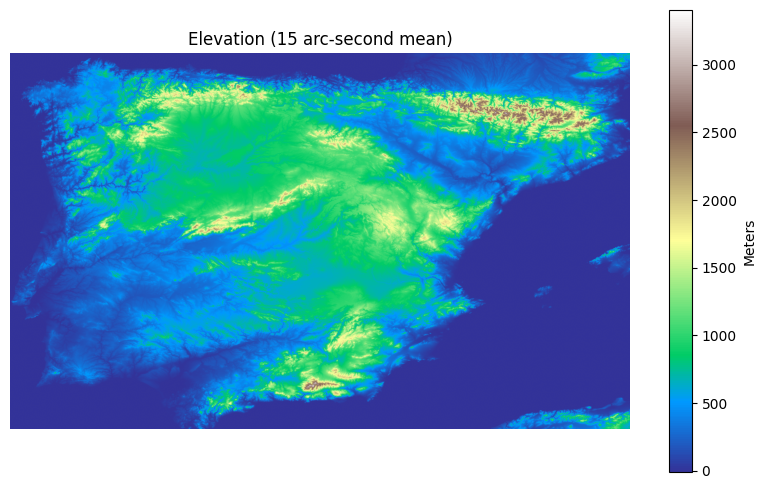

In [17]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Choose one TIFF file to display
filename = "usgs_gmted2010_15arcsec_mean_stat_GJSlAGGFa3xA6diXXPiM.tiff"
filepath = os.path.join(tiff_dir, filename)

# Open the GeoTIFF
with rasterio.open(filepath) as src:
    elevation = src.read(1)  # Read the first band
    profile = src.profile

# Mask invalid values (optional)
elevation = np.where(elevation == src.nodata, np.nan, elevation)

# Plot
plt.figure(figsize=(10, 6))
plt.imshow(elevation, cmap='terrain')
plt.title("Elevation (15 arc-second mean)")
plt.colorbar(label="Meters")
plt.axis("off")
plt.show()


hnh

In [18]:
!pip install rasterio geopandas matplotlib shapely


---
**Descargar el shapefile de países (Natural Earth)**

---

[Natural Earth](https://www.naturalearthdata.com/) is a public domain map dataset available at 1:10m, 1:50m, and 1:110 million scales. Featuring tightly integrated vector and raster data, with Natural Earth you can make a variety of visually pleasing, well-crafted maps with cartography or GIS software.

Natural Earth was built through a collaboration of many [volunteers](https://www.naturalearthdata.com/about/contributors/) and is supported by [NACIS (North American Cartographic Information Society)](http://www.nacis.org/), and is free for use in any type of project (see our Terms of Use page for more information).


In [30]:
import geopandas as gpd
from shapely.geometry import mapping
from rasterio import mask as msk

df = gpd.read_file('https://www.naturalearthdata.com/downloads/10m-cultural-vectors/ne_10m_admin_0_countries.shp')

italy = df.loc[df['ADMIN'] == 'Italy']

clipped_array, clipped_transform = msk.mask(file, [mapping(italy.iloc[0].geometry)], crop=True)

plt.imshow(clipped_array[0], cmap='Spectral')
plt.show()

HTTPError: HTTP Error 406: Not Acceptable

In [25]:
import geopandas as gpd

# Cargar los países desde el dataset "naturalearth_lowres"
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

# Filtrar solo España
spain = world[world["name"] == "Spain"]
spain = spain.to_crs("EPSG:4326")  # Asegurar que esté en el mismo sistema que el raster


AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

In [26]:
# Descargar el shapefile de países (1:110m - baja resolución)
!wget https://www.naturalearthdata.com/http//www.naturalearthdata.com/download/110m/cultural/ne_110m_admin_0_countries.zip -O countries.zip

# Descomprimir
!unzip countries.zip -d countries_shapefile


--2025-07-25 08:07:01--  https://www.naturalearthdata.com/http//www.naturalearthdata.com/download/110m/cultural/ne_110m_admin_0_countries.zip
Resolving www.naturalearthdata.com (www.naturalearthdata.com)... 50.87.253.14
Connecting to www.naturalearthdata.com (www.naturalearthdata.com)|50.87.253.14|:443... connected.
HTTP request sent, awaiting response... 500 Internal Server Error
2025-07-25 08:07:02 ERROR 500: Internal Server Error.

Archive:  countries.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of countries.zip or
        countries.zip.zip, and cannot find countries.zip.ZIP, period.


In [27]:
!wget https://www.naturalearthdata.com/download/110m/cultural/ne_110m_admin_0_countries.zip -O countries.zip
!unzip -o countries.zip -d countries_shapefile


--2025-07-25 08:07:34--  https://www.naturalearthdata.com/download/110m/cultural/ne_110m_admin_0_countries.zip
Resolving www.naturalearthdata.com (www.naturalearthdata.com)... 50.87.253.14
Connecting to www.naturalearthdata.com (www.naturalearthdata.com)|50.87.253.14|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-07-25 08:07:35 ERROR 404: Not Found.

Archive:  countries.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of countries.zip or
        countries.zip.zip, and cannot find countries.zip.ZIP, period.


In [24]:
import geopandas as gpd
import zipfile
import os

# Define the expected zip file and extracted directory names
zip_file = "110m_cultural_vectors.zip"
extracted_dir = "110m_cultural_vectors"

# Check if the zip file exists in the current directory
if os.path.exists(zip_file):
    print(f"{zip_file} found. Extracting...")
    # Extract the zip file if the extracted directory doesn't exist
    if not os.path.exists(extracted_dir):
        try:
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(extracted_dir)
            print("Extraction complete.")
        except Exception as e:
            print(f"Error during extraction: {e}")
            extracted_dir = None # Set extracted_dir to None if extraction fails
    else:
        print(f"{extracted_dir} already exists. Skipping extraction.")

    # Path to the shapefile within the extracted directory
    if extracted_dir and os.path.exists(extracted_dir):
        shp_path = os.path.join(extracted_dir, "ne_110m_admin_0_countries.shp")

        # Cargar los países desde el shapefile si shp_path exists
        if os.path.exists(shp_path):
            world = gpd.read_file(shp_path)

            # Filter for France
            france = world[world["name"] == "France"]
            france = france.to_crs("EPSG:4326")  # Ensure it's in the same system as the raster

            print("France GeoDataFrame loaded successfully.")
        else:
            print(f"Shapefile not found at {shp_path}. Please ensure the zip file was extracted correctly.")
    else:
        print("Could not find or create the extracted directory.")

else:
    print(f"'{zip_file}' not found in the current directory ({os.getcwd()}). Please upload the file manually.")

'110m_cultural_vectors.zip' not found in the current directory (/content/datasets). Please upload the file manually.


* * *
**Clip the GMTED2010 data to the extent of France**

* * *

Now we will use the loaded France shapefile to clip the elevation data. This will create a new GeoTIFF file containing only the elevation data for France.

In [23]:
import rasterio
from rasterio.mask import mask
import numpy as np
import os

# Path to the downloaded GMTED2010 data (choose one of the TIFF files)
# We'll use the 15 arc-second mean elevation data as an example
gmted_file = "GMTED/usgs_gmted2010_15arcsec_mean_stat_GJSlAGGFa3xA6diXXPiM.tiff"
gmted_filepath = os.path.join(tiff_dir, gmted_file) # Use the previously defined tiff_dir

# Output filename for the clipped raster
output_clipped_raster = "france_gmted_clipped.tif"

# Ensure the France GeoDataFrame is available (from the previous cell)
if 'france' in locals() and not france.empty:
    # Get the geometry of France
    geometries = france.geometry.values

    # Open the GMTED2010 raster
    with rasterio.open(gmted_filepath) as src:
        # Clip the raster using the France geometry
        out_image, out_transform = mask(src, geometries, crop=True)
        out_meta = src.meta.copy()

        # Update the metadata for the clipped raster
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "nodata": src.nodata # Keep the original nodata value
        })

        # Write the clipped raster to a new file
        with rasterio.open(output_clipped_raster, "w", **out_meta) as dest:
            dest.write(out_image)

    print(f"Clipped raster saved as {output_clipped_raster}")

else:
    print("France GeoDataFrame not found. Please run the previous cell to load the France shapefile.")

France GeoDataFrame not found. Please run the previous cell to load the France shapefile.


In [51]:
print(os.getcwd())

!mkdir -p countries_shapefile

!wget -q -O countries_shapefile/ne_10m_admin_0_countries.shp https://github.com/nvkelso/natural-earth-vector/raw/master/10m_cultural/ne_10m_admin_0_countries.shp
!wget -q -O countries_shapefile/ne_10m_admin_0_countries.shx https://github.com/nvkelso/natural-earth-vector/raw/master/10m_cultural/ne_10m_admin_0_countries.shx
!wget -q -O countries_shapefile/ne_10m_admin_0_countries.dbf https://github.com/nvkelso/natural-earth-vector/raw/master/10m_cultural/ne_10m_admin_0_countries.dbf
!wget -q -O countries_shapefile/ne_10m_admin_0_countries.prj https://github.com/nvkelso/natural-earth-vector/raw/master/10m_cultural/ne_10m_admin_0_countries.prj
!wget -q -O countries_shapefile/ne_10m_admin_0_countries.cpg https://github.com/nvkelso/natural-earth-vector/raw/master/10m_cultural/ne_10m_admin_0_countries.cpg


/content/datasets


In [52]:
!tree $countries_shapefile -L 2

.
├── countries_shapefile
│   ├── ne_10m_admin_0_countries.cpg
│   ├── ne_10m_admin_0_countries.dbf
│   ├── ne_10m_admin_0_countries.prj
│   ├── ne_10m_admin_0_countries.shp
│   ├── ne_10m_admin_0_countries.shx
│   ├── ne_110m_admin_0_countries.cpg
│   ├── ne_110m_admin_0_countries.dbf
│   ├── ne_110m_admin_0_countries.prj
│   ├── ne_110m_admin_0_countries.shp
│   └── ne_110m_admin_0_countries.shx
├── countries.zip
├── GMTED
│   ├── gmted2010_fgdc_metadata_updated_final_1.xml
│   ├── Spatial Metadata
│   ├── usgs_gmted2010_15arcsec_breakline_emphasis_GJSlAGGFa3xA6diXXPiM.tiff
│   ├── usgs_gmted2010_15arcsec_maximum_stat_GJSlAGGFa3xA6diXXPiM.tiff
│   ├── usgs_gmted2010_15arcsec_mean_stat_GJSlAGGFa3xA6diXXPiM.tiff
│   ├── usgs_gmted2010_15arcsec_median_stat_GJSlAGGFa3xA6diXXPiM.tiff
│   ├── usgs_gmted2010_15arcsec_minimum_stat_GJSlAGGFa3xA6diXXPiM.tiff
│   ├── usgs_gmted2010_15arcsec_standarddev_stat_GJSlAGGFa3xA6diXXPiM.tiff
│   ├── usgs_gmted2010_15arcsec_systematic_subsample_GJSlAGGFa

---
**Read shapefile  from spain**

---

In [53]:
import geopandas as gpd

# Cargar shapefile
world = gpd.read_file("countries_shapefile/ne_10m_admin_0_countries.shp")

# Filtrar España
spain = world[world["NAME"] == "Spain"]

# Asegurar CRS WGS84
spain = spain.to_crs("EPSG:4326")

print(spain)


         featurecla  scalerank  LABELRANK SOVEREIGNT SOV_A3  ADM0_DIF  LEVEL  \
66  Admin-0 country          0          2      Spain    ESP         0      2   

                 TYPE TLC  ADMIN  ... FCLASS_TR  FCLASS_ID FCLASS_PL  \
66  Sovereign country   1  Spain  ...      None       None      None   

   FCLASS_GR  FCLASS_IT FCLASS_NL FCLASS_SE  FCLASS_BD FCLASS_UA  \
66      None       None      None      None       None      None   

                                             geometry  
66  MULTIPOLYGON (((-5.34073 35.84736, -5.3629 35....  

[1 rows x 169 columns]


In [54]:
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt

# Abrir el raster (pon la ruta correcta de tu archivo)
raster_path = "GMTED/usgs_gmted2010_15arcsec_mean_stat_GJSlAGGFa3xA6diXXPiM.tiff"

with rasterio.open(raster_path) as src:
    # Recortar usando la geometría de España
    out_image, out_transform = mask(src, spain.geometry, crop=True)
    out_meta = src.meta.copy()

# Actualizar metadatos para el nuevo raster recortado
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# Guardar raster recortado
recortado_path = "raster_recortado_espana.tif"
with rasterio.open(recortado_path, "w", **out_meta) as dest:
    dest.write(out_image)


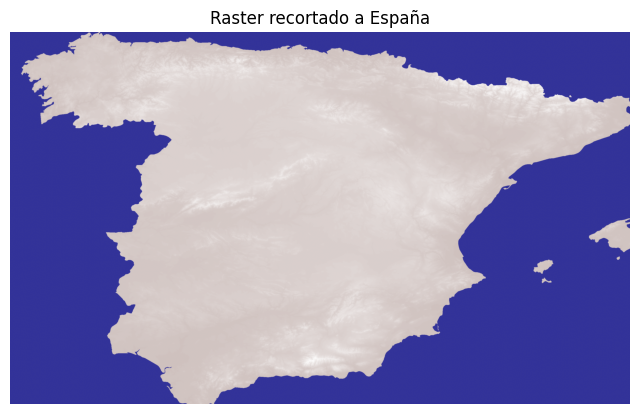

In [55]:
with rasterio.open(recortado_path) as src:
    fig, ax = plt.subplots(figsize=(8, 8))
    raster_plot = src.read(1)
    ax.imshow(raster_plot, cmap='terrain')
    ax.set_title("Raster recortado a España")
    plt.axis('off')
    plt.show()
